# Part D — Performance Analysis and Graphs

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns

In [3]:
df = pd.read_excel("cleaned_data.xlsx")

In [4]:
df.head()

,student_id,branch,track,gender,age,study_hours_week,commute_minutes,sleep_hours,projects_submitted,satisfaction_1to5,has_laptop,transport,pets_at_home,favorite_sport,final_score
0,ITI-1031,Cairo,Data Science,Male,21.0,16.5,34.1,5.5,2,3.0,Yes,Car,0.0,Swimming,79.3
1,ITI-1117,Assiut,Data Science,Female,29.0,25.1,5.0,6.6,3,4.0,Yes,Metro,1.0,Football,91.7
2,ITI-1080,Cairo,Data Science,Male,25.0,14.1,73.2,7.7,0,4.0,Yes,Bus,0.0,NaN,79.3
3,ITI-1128,Cairo,Web Development,Female,25.0,NaN,13.7,6.3,2,4.0,Yes,Metro,1.0,NaN,90.6
4,ITI-1197,Menoufia,Web Development,Male,25.0,19.9,17.2,6.9,3,3.0,No,Car,0.0,NaN,86.8


In [5]:
df.columns

Index(['student_id', 'branch', 'track', 'gender', 'age', 'study_hours_week',
       'commute_minutes', 'sleep_hours', 'projects_submitted',
       'satisfaction_1to5', 'has_laptop', 'transport', 'pets_at_home',
       'favorite_sport', 'final_score'],
      dtype='object')

In [6]:
df[["commute_minutes","final_score","study_hours_week","sleep_hours"]].describe()

,commute_minutes,final_score,study_hours_week,sleep_hours
count,259.000000,257.000000,253.000000,250.00000
mean,45.087645,79.503502,16.464032,6.83960
std,39.301972,9.777135,5.279145,1.09199
min,5.000000,50.400000,2.000000,3.80000
25%,20.550000,72.900000,12.800000,6.10000
50%,33.000000,78.900000,16.700000,6.80000
75%,58.300000,86.300000,20.200000,7.50000
max,256.500000,100.000000,30.800000,9.50000


### D1 — Relationship Interpretation

In [7]:
df[["commute_minutes","final_score","study_hours_week","sleep_hours"]].corr()

,commute_minutes,final_score,study_hours_week,sleep_hours
commute_minutes,1.000000,-0.059312,0.110713,0.023276
final_score,-0.059312,1.000000,0.644874,0.164320
study_hours_week,0.110713,0.644874,1.000000,-0.005734
sleep_hours,0.023276,0.164320,-0.005734,1.000000


In [9]:
print("Commute vs Final Score:",
      df["commute_minutes"].corr(df["final_score"]))

print("Study Hours vs Final Score:",
      df["study_hours_week"].corr(df["final_score"]))

print("Sleep Hours vs Final Score:",
      df["sleep_hours"].corr(df["final_score"]))

Commute vs Final Score: -0.059312138881173745
Study Hours vs Final Score: 0.6448738558321664
Sleep Hours vs Final Score: 0.16431955415565438


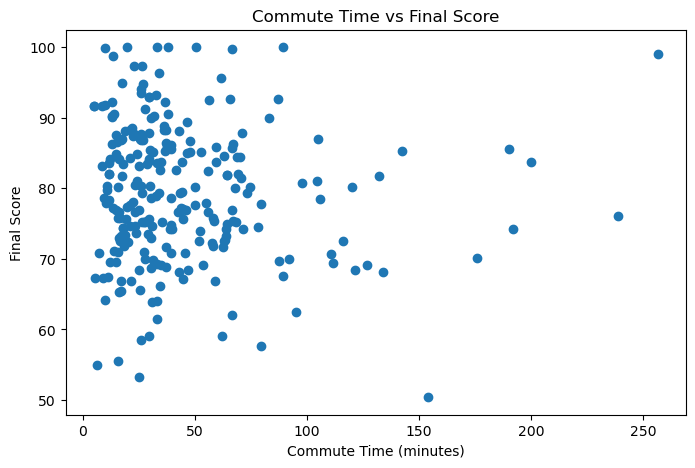

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(df["commute_minutes"], df["final_score"])

plt.xlabel("Commute Time (minutes)")
plt.ylabel("Final Score")
plt.title("Commute Time vs Final Score")

plt.show()

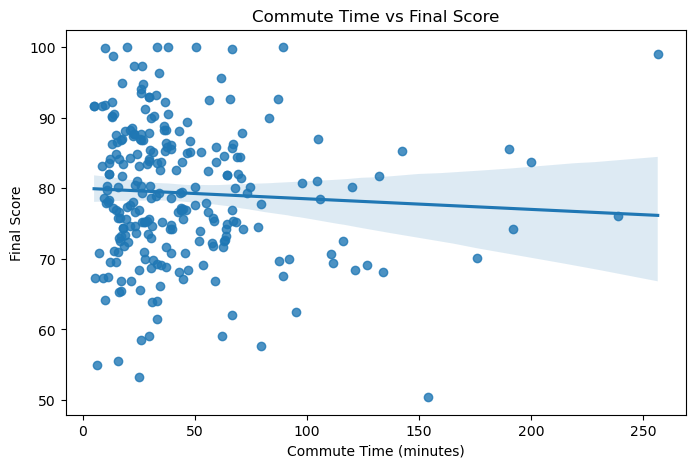

In [11]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="commute_minutes",
    y="final_score"
)

plt.xlabel("Commute Time (minutes)")
plt.ylabel("Final Score")
plt.title("Commute Time vs Final Score")

plt.show()

In [13]:
correlations = {
    "Commute vs Final Score": df["commute_minutes"].corr(df["final_score"]),
    "Study Hours vs Final Score": df["study_hours_week"].corr(df["final_score"]),
    "Sleep Hours vs Final Score": df["sleep_hours"].corr(df["final_score"])
}

correlation_df = pd.DataFrame(
    correlations.items(),
    columns=["Relationship", "Correlation"]
)

correlation_df

,Relationship,Correlation
0,Commute vs Final Score,-0.059312
1,Study Hours vs Final Score,0.644874
2,Sleep Hours vs Final Score,0.164320


### D1 : Relationship Interpretation

- Commute time and final score have a very weak negative correlation (r = -0.0593), suggesting almost no linear relationship between commute time and final score.

- Study hours and final score have a moderate-to-strong positive correlation (r = 0.6449), suggesting that students who study more tend to have higher final scores.

- Sleep hours and final score have a weak positive correlation (r = 0.1643), suggesting only a small linear relationship between sleep hours and final score.

## D2 — Correlation != Causation

A correlation between commute time and final score does not prove that commute time causes lower scores.

### Alternative explanations

1. Students with longer commute times may have less time available for studying, so study hours could partly explain the relationship.

2. Other factors, such as socioeconomic conditions or home environment, may be related to both commute time and academic performance.

### Data needed to test causation

To investigate causality, we would need longitudinal data or, when feasible and ethical, a randomized experiment. The study should also measure and control for important confounding factors such as study hours and other relevant student characteristics.

In [14]:
# Calculate Median, Q1, Q3 and IQR

median_commute = df['commute_minutes'].median()

Q1 = df['commute_minutes'].quantile(0.25)

Q3 = df['commute_minutes'].quantile(0.75)

IQR = Q3 - Q1

# Upper IQR Fence
upper_fence = Q3 + (1.5 * IQR)

print("Median:", median_commute)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper IQR Fence:", upper_fence)

Median: 33.0
Q1: 20.549999999999997
Q3: 58.3
IQR: 37.75
Upper IQR Fence: 114.925


In [15]:
# Compare the three possible thresholds

thresholds = {
    'Median': median_commute,
    'Q3': Q3,
    'Upper IQR Fence': upper_fence
}

for name, threshold in thresholds.items():
    long_count = (df['commute_minutes'] > threshold).sum()
    short_count = (df['commute_minutes'] <= threshold).sum()

    print(f"\n{name}: {threshold}")
    print("Short commute:", short_count)
    print("Long commute:", long_count)


Median: 33.0
Short commute: 130
Long commute: 129

Q3: 58.3
Short commute: 194
Long commute: 65

Upper IQR Fence: 114.925
Short commute: 244
Long commute: 15


# The selected threshold is : 
 Q3 = 58.3 minutes.

### Why was Q3 selected?

Q3 was selected because it identifies the top 25% of students with the longest commute times.
It creates a clear distinction between relatively shorter and longer commutes while keeping enough students in both groups for comparison.
+It is more logic : less than hour is a short commute.

In [16]:
# Define Q3 as the threshold
threshold = Q3

# Create the two groups
short_commute = df[df['commute_minutes'] <= threshold]

long_commute = df[df['commute_minutes'] > threshold]

# Check the number of students in each group
print("Short commute:", len(short_commute))
print("Long commute:", len(long_commute))

Short commute: 194
Long commute: 65


Using Q3 = 58.3 minutes as the threshold:

- Short commute group: 194 students
- Long commute group: 65 students

In [17]:
# Statistics for Short Commute group
print("Short Commute - Final Score")
print("Mean:", short_commute['final_score'].mean())
print("Median:", short_commute['final_score'].median())
print("Standard Deviation:", short_commute['final_score'].std())

print("\n------------------------\n")

# Statistics for Long Commute group
print("Long Commute - Final Score")
print("Mean:", long_commute['final_score'].mean())
print("Median:", long_commute['final_score'].median())
print("Standard Deviation:", long_commute['final_score'].std())

Short Commute - Final Score
Mean: 79.78783068783068
Median: 79.3
Standard Deviation: 9.570055806597663

------------------------

Long Commute - Final Score
Mean: 78.02258064516128
Median: 78.15
Standard Deviation: 10.043926789968264


In [18]:
# Calculate the difference between the two means

mean_gap = (
    short_commute['final_score'].mean()
    - long_commute['final_score'].mean()
)

# Get the standard deviation of each group

short_sd = short_commute['final_score'].std()
long_sd = long_commute['final_score'].std()

# Print the results

print("Mean gap:", mean_gap)
print("Short commute SD:", short_sd)
print("Long commute SD:", long_sd)

Mean gap: 1.7652500426693933
Short commute SD: 9.570055806597663
Long commute SD: 10.043926789968264


## Q2
The mean final score for short-commute students is 79.79, 
compared to 78.02 for long-commute students, resulting in a mean gap of 1.77 points. This gap is small compared to the standard deviations within both groups 
(9.57 and 10.04), suggesting that the difference in average scores is relatively small compared with the variation among students within each group

## Q3
No, we would not expect exactly the same gap because 
different samples may produce different results.
 The difference between a sample statistic and the true population parameter is called sampling error.

# D4 — Choose the Right Graph

### 1. The shape of the commute-time distribution across all students
- Graph: Histogram
- Why: It shows the distribution and shape of a quantitative variable.

### 2. Commute times are concentrated at the low end with a long tail
- Graph: Histogram
- Why: It helps visualize the skewness and the long right tail of commute times.

### 3. A side-by-side comparison of commute time across all five branches
- Graph: Box Plot
- Why: It compares the median, spread, and outliers of a quantitative variable across different branches.

### 4. The relationship between study hours and final score
- Graph: Scatter Plot
- Why: It shows the relationship between two quantitative variables.

### 5. The breakdown of preferred transport modes
- Graph: Bar Chart
- Why: It displays the frequency of categories in a qualitative nominal variable.

### 6. How many students fall into each satisfaction level, 1 to 5
- Graph: Bar Chart
- Why: Satisfaction level is an ordinal variable, even though it is stored as numbers.

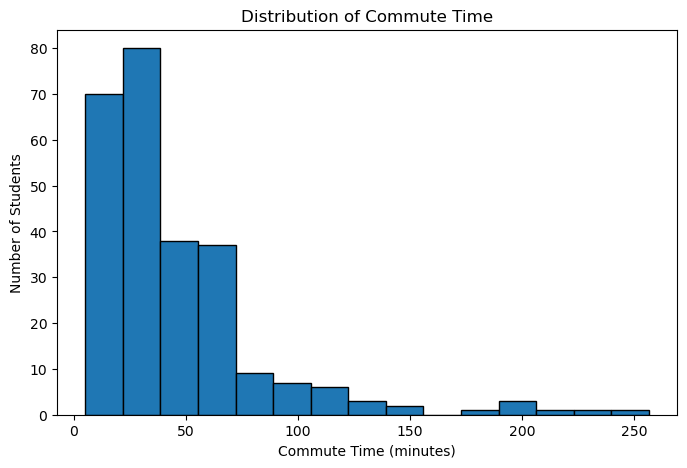

In [ ]:
# Histogram of Commute Time
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df['commute_minutes'], bins=15, edgecolor='black')

plt.title('Distribution of Commute Time')
plt.xlabel('Commute Time (minutes)')
plt.ylabel('Number of Students')

plt.show()

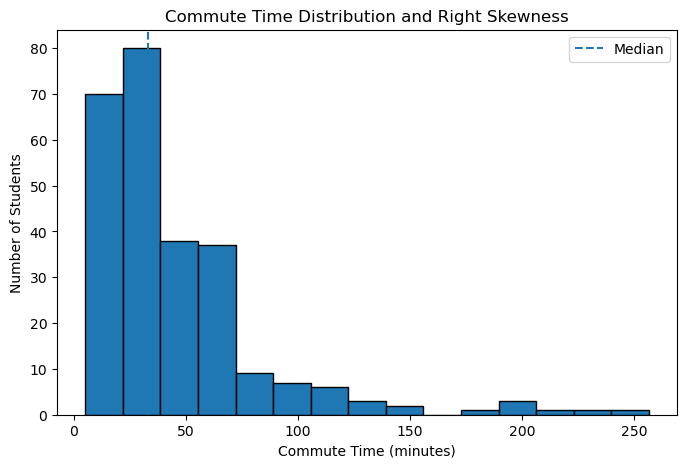

In [20]:
#Commute Time with Long Right Tail
plt.figure(figsize=(8, 5))

plt.hist(df['commute_minutes'], bins=15, edgecolor='black')

plt.axvline(
    df['commute_minutes'].median(),
    linestyle='--',
    label='Median'
)

plt.title('Commute Time Distribution and Right Skewness')
plt.xlabel('Commute Time (minutes)')
plt.ylabel('Number of Students')

plt.legend()
plt.show()

## The distribution is concentrated at lower commute times and has a long right tail, indicating positive skewness.

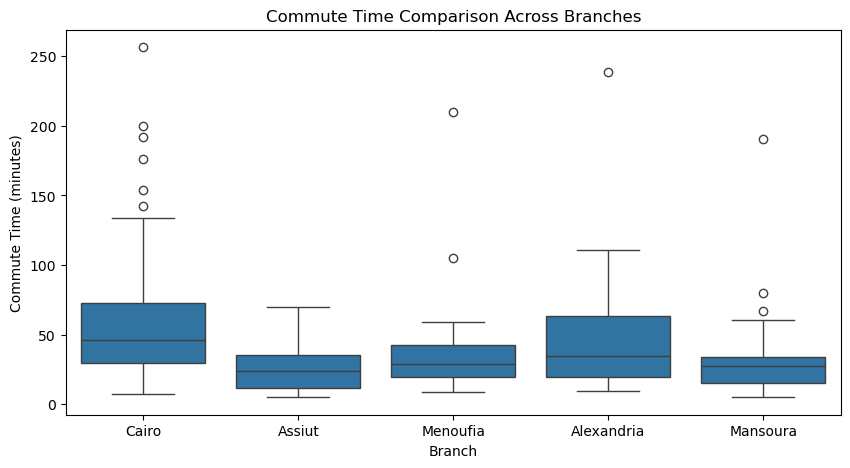

In [21]:
#Box Plot of Commute Time by Branch
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='branch',
    y='commute_minutes'
)

plt.title('Commute Time Comparison Across Branches')
plt.xlabel('Branch')
plt.ylabel('Commute Time (minutes)')

plt.show()

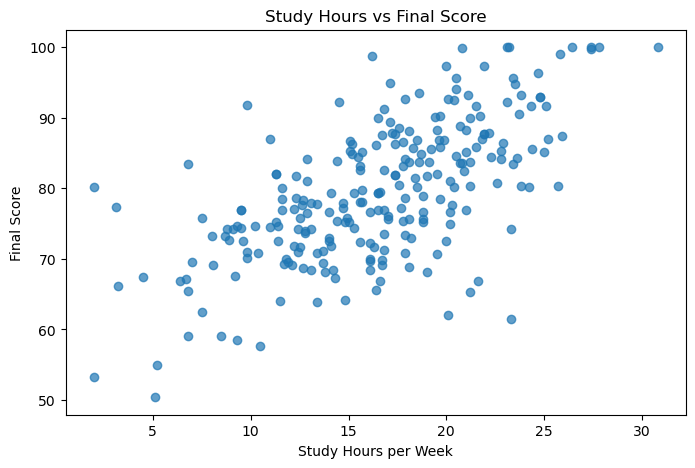

In [22]:
#Scatter Plot: Study Hours vs Final Score
plt.figure(figsize=(8, 5))

plt.scatter(
    df['study_hours_week'],
    df['final_score'],
    alpha=0.7
)

plt.title('Study Hours vs Final Score')
plt.xlabel('Study Hours per Week')
plt.ylabel('Final Score')

plt.show()

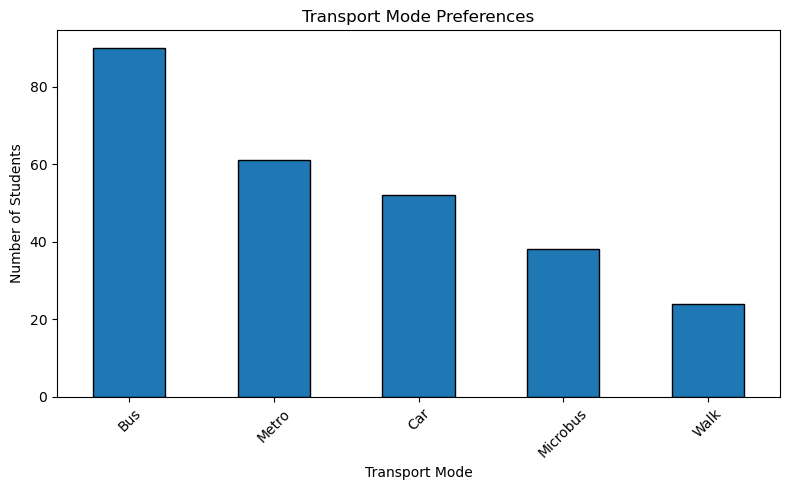

In [25]:
#Bar Chart: Preferred Transport Modes
transport_counts = df['transport'].value_counts()

plt.figure(figsize=(8, 5))

transport_counts.plot(kind='bar', edgecolor='black')

plt.title('Transport Mode Preferences')
plt.xlabel('Transport Mode')
plt.ylabel('Number of Students')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

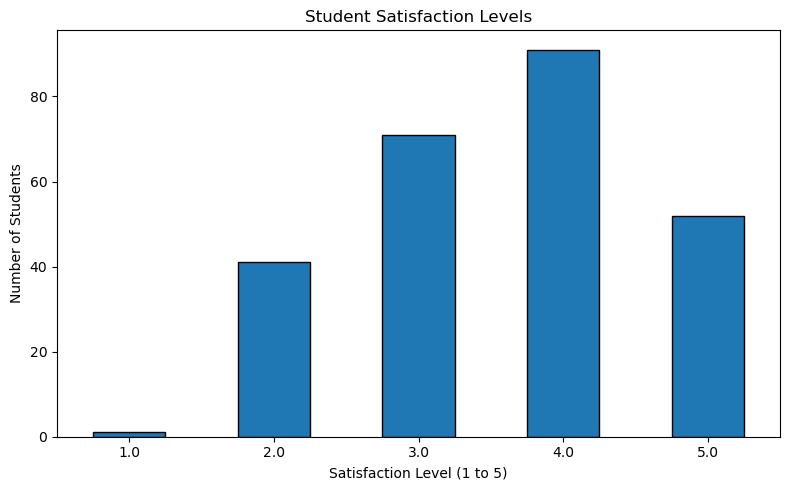

In [24]:
#Bar Chart: Satisfaction Levels
satisfaction_counts = df['satisfaction_1to5'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

satisfaction_counts.plot(kind='bar', edgecolor='black')

plt.title('Student Satisfaction Levels')
plt.xlabel('Satisfaction Level (1 to 5)')
plt.ylabel('Number of Students')

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()